# Notebook 6: Swin UNETR-Based Classification Model

## Objective

This notebook builds the deep learning model for automated lumbar spine
disease classification.

Tasks:

- Environment setup
- MONAI configuration
- GPU verification
- Load Dataset
- Model configuration

In [31]:
# ============================================================
# Project Setup
# ============================================================

import os
import sys

PROJECT_ROOT = os.path.abspath("..")

if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

print("PROJECT_ROOT =", PROJECT_ROOT)
print("src exists:", os.path.exists(os.path.join(PROJECT_ROOT, "src")))

PROJECT_ROOT = d:\Msc Major Project Swin Unetr Framework\MSc_SwinUNETR_Project
src exists: True


In [32]:
from src.config import *

print("config.py imported successfully!")

config.py imported successfully!


In [ ]:
from src.utils import *

print("utils.py imported successfully!")

utils.py imported successfully!


In [35]:
from src.data_loader import LumbarDataset

In [1]:
# ============================================================
# Standard Libraries
# ============================================================

import os
import random
import warnings

warnings.filterwarnings("ignore")

In [2]:
# ============================================================
# Scientific Libraries
# ============================================================

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

In [3]:
# ============================================================
# PyTorch
# ============================================================

import torch
import torch.nn as nn
import torchvision

print("Torch Version :", torch.__version__)
print("TorchVision :", torchvision.__version__)

Torch Version : 2.11.0+cu128
TorchVision : 0.26.0+cu128


In [4]:
# ============================================================
# MONAI
# ============================================================

import monai

print("MONAI Version :", monai.__version__)

MONAI Version : 1.6.0


In [7]:
# ============================================================
# TorchInfo
# ============================================================

from torchinfo import summary

In [8]:
# ============================================================
# TensorBoard
# ============================================================

from torch.utils.tensorboard import SummaryWriter

In [9]:
# ============================================================
# Scikit-learn
# ============================================================

from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score

In [20]:
# ============================================================
# Project Paths
# ============================================================

import os

PROJECT_ROOT = r"D:\Msc Major Project Swin Unetr Framework\MSc_SwinUNETR_Project"

DATASET_DIR = os.path.join(
    PROJECT_ROOT,
    "dataset",
    "rsna-2024-lumbar-spine-degenerative-classification"
)

OUTPUT_DIR = os.path.join(
    PROJECT_ROOT,
    "outputs"
)

MODEL_DIR = os.path.join(
    PROJECT_ROOT,
    "models"
)

TABLE_DIR = os.path.join(
    OUTPUT_DIR,
    "tables"
)

FIGURE_DIR = os.path.join(
    OUTPUT_DIR,
    "figures"
)

LOG_DIR = os.path.join(
    OUTPUT_DIR,
    "logs"
)

os.makedirs(MODEL_DIR, exist_ok=True)
os.makedirs(TABLE_DIR, exist_ok=True)
os.makedirs(FIGURE_DIR, exist_ok=True)
os.makedirs(LOG_DIR, exist_ok=True)

print("Project Root :", PROJECT_ROOT)

Project Root : D:\Msc Major Project Swin Unetr Framework\MSc_SwinUNETR_Project


In [10]:
# ============================================================
# Device
# ============================================================

DEVICE = torch.device(

    "cuda"

    if torch.cuda.is_available()

    else "cpu"

)

print("Device :", DEVICE)

Device : cuda


In [11]:
print("CUDA Available :", torch.cuda.is_available())

if torch.cuda.is_available():

    print("GPU :", torch.cuda.get_device_name(0))

    print("CUDA Version :", torch.version.cuda)

CUDA Available : True
GPU : NVIDIA GeForce RTX 2050
CUDA Version : 12.8


In [12]:
# ============================================================
# Random Seed
# ============================================================

SEED = 42

random.seed(SEED)

np.random.seed(SEED)

torch.manual_seed(SEED)

torch.cuda.manual_seed_all(SEED)

print("Seed Fixed :", SEED)

Seed Fixed : 42


In [13]:
# ============================================================
# Hyperparameters
# ============================================================

IMAGE_SIZE = 224

NUM_CHANNELS = 3

NUM_CLASSES = 3

BATCH_SIZE = 4

print("Image Size :", IMAGE_SIZE)

print("Channels :", NUM_CHANNELS)

print("Classes :", NUM_CLASSES)

print("Batch Size :", BATCH_SIZE)

Image Size : 224
Channels : 3
Classes : 3
Batch Size : 4


In [14]:
# ============================================================
# Training Hyperparameters
# ============================================================

LEARNING_RATE = 1e-4

WEIGHT_DECAY = 1e-5

EPOCHS = 25

print("Learning Rate :", LEARNING_RATE)

print("Epochs :", EPOCHS)

Learning Rate : 0.0001
Epochs : 25


In [18]:
# ============================================================
# Output Directories
# ============================================================

print("Model Directory :", MODEL_DIR)

print("Log Directory :", LOG_DIR)

print("Figure Directory :", FIGURE_DIR)

print("Table Directory :", TABLE_DIR)

Model Directory : D:\Msc Major Project Swin Unetr Framework\MSc_SwinUNETR_Project\models
Log Directory : D:\Msc Major Project Swin Unetr Framework\MSc_SwinUNETR_Project\outputs\logs
Figure Directory : D:\Msc Major Project Swin Unetr Framework\MSc_SwinUNETR_Project\outputs\figures
Table Directory : D:\Msc Major Project Swin Unetr Framework\MSc_SwinUNETR_Project\outputs\tables


In [21]:
print(MODEL_DIR)

print(LOG_DIR)

print(FIGURE_DIR)

D:\Msc Major Project Swin Unetr Framework\MSc_SwinUNETR_Project\models
D:\Msc Major Project Swin Unetr Framework\MSc_SwinUNETR_Project\outputs\logs
D:\Msc Major Project Swin Unetr Framework\MSc_SwinUNETR_Project\outputs\figures


In [22]:
# ============================================================
# TensorBoard
# ============================================================

writer = SummaryWriter(

    log_dir=LOG_DIR

)

print("TensorBoard Ready")

TensorBoard Ready


In [24]:
print("Preparing Dataset...")

Preparing Dataset...


In [34]:
import os

data_loader_path = os.path.join(PROJECT_ROOT, "src", "data_loader.py")

print(data_loader_path)

D:\Msc Major Project Swin Unetr Framework\MSc_SwinUNETR_Project\src\data_loader.py


In [37]:
import pandas as pd
import os

DATASET_DIR = r"D:\Msc Major Project Swin Unetr Framework\MSc_SwinUNETR_Project\dataset\rsna-2024-lumbar-spine-degenerative-classification"

TRAIN_IMAGES = os.path.join(DATASET_DIR, "train_images")

train_df = pd.read_csv(os.path.join(DATASET_DIR, "train.csv"))

coord_df = pd.read_csv(os.path.join(DATASET_DIR, "train_label_coordinates.csv"))

print(train_df.shape)
print(coord_df.shape)

(1975, 26)
(48692, 7)


In [38]:
master_df = coord_df.copy()

print(master_df.shape)
master_df.head()

(48692, 7)


,study_id,series_id,instance_number,condition,level,x,y
0,4003253,702807833,8,Spinal Canal Stenosis,L1/L2,322.831858,227.964602
1,4003253,702807833,8,Spinal Canal Stenosis,L2/L3,320.571429,295.714286
2,4003253,702807833,8,Spinal Canal Stenosis,L3/L4,323.030303,371.818182
3,4003253,702807833,8,Spinal Canal Stenosis,L4/L5,335.292035,427.327434
4,4003253,702807833,8,Spinal Canal Stenosis,L5/S1,353.415929,483.964602


In [41]:
dataset = LumbarDataset(

    dataframe=master_df,

    train_df=train_df,

    train_images=TRAIN_IMAGES

)

print("Dataset Size :", len(dataset))

Dataset Size : 48692


In [42]:
from torch.utils.data import random_split

train_size = int(0.8 * len(dataset))

valid_size = len(dataset) - train_size

train_dataset, valid_dataset = random_split(

    dataset,

    [train_size, valid_size],

    generator=torch.Generator().manual_seed(42)

)

print("Training :", len(train_dataset))
print("Validation :", len(valid_dataset))

Training : 38953
Validation : 9739


In [43]:
from torch.utils.data import DataLoader

train_loader = DataLoader(

    train_dataset,

    batch_size=4,

    shuffle=True,

    num_workers=0

)

valid_loader = DataLoader(

    valid_dataset,

    batch_size=4,

    shuffle=False,

    num_workers=0

)

print("DataLoader Ready")

DataLoader Ready


In [44]:
# ============================================================
# Load DataLoader
# ============================================================

print("Training Samples :", len(train_dataset))

print("Validation Samples :", len(valid_dataset))

Training Samples : 38953
Validation Samples : 9739


In [45]:
batch = next(iter(train_loader))

print(batch["image"].shape)

print(batch["label"].shape)

torch.Size([4, 3, 224, 224])
torch.Size([4])


In [46]:
print(batch["image"].dtype)

print(batch["label"].dtype)

torch.float32
torch.int64


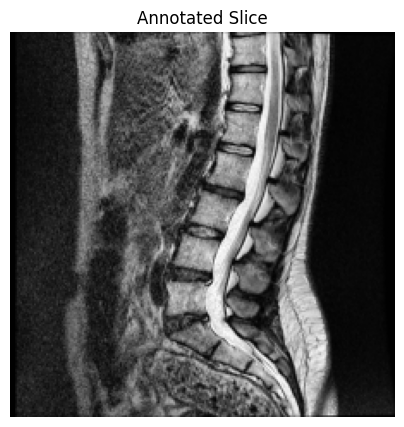

In [47]:
plt.figure(figsize=(5,5))

plt.imshow(

    batch["image"][0][1].cpu().numpy(),

    cmap="gray"

)

plt.title("Annotated Slice")

plt.axis("off")

plt.show()

In [48]:
print("Pixel Minimum :", batch["image"].min())

print("Pixel Maximum :", batch["image"].max())

Pixel Minimum : tensor(0.0039)
Pixel Maximum : tensor(0.9922)


In [49]:
environment_summary = pd.DataFrame({

    "Parameter":[

        "Device",

        "Image Size",

        "Channels",

        "Classes",

        "Batch Size",

        "Learning Rate",

        "Epochs"

    ],

    "Value":[

        str(DEVICE),

        IMAGE_SIZE,

        NUM_CHANNELS,

        NUM_CLASSES,

        BATCH_SIZE,

        LEARNING_RATE,

        EPOCHS

    ]

})

environment_summary

,Parameter,Value
0,Device,cuda
1,Image Size,224
2,Channels,3
3,Classes,3
4,Batch Size,4
5,Learning Rate,0.0001
6,Epochs,25


In [50]:
environment_summary.to_csv(

    os.path.join(

        TABLE_DIR,

        "environment_summary.csv"

    ),

    index=False

)

print("Environment Summary Saved.")

Environment Summary Saved.


In [51]:
print("="*60)

print("Notebook 6 - Module 1 Completed")

print("="*60)

Notebook 6 - Module 1 Completed


# Module 1 Summary

Completed:

- Imported required libraries
- Verified GPU
- Configured MONAI
- Fixed random seed
- Configured hyperparameters
- Verified DataLoader
- Initialized TensorBoard

## Next Module

**Module 2 – Swin UNETR-Based Classification Model**

We will:

- Build the Swin UNETR backbone
- Add a classification head
- Configure the forward pass
- Verify the model architecture
- Count trainable parameters